In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 0 Define the f, exact

def f(t, y):
    return y - (0.5 * np.exp(0.5*t) * np.sin(5*t)) \
        + (5*np.exp(0.5*t) * np.cos(5*t))

def exact(t):
    return np.exp(0.5*t) * np.sin(5*t)

In [ ]:
# 1 Calculation (Euler-)

t0 = 0.0
T = 5.0
y0 = 0
nt_list = [10, 20, 40, 100, 200, 400]
results = []
prev_h = None # step size h 저장 변수
prev_max_err = None # 최대오차 저장 변수

for nt in nt_list:
    # step size, t, y, euler, exact, error, order, results
    h = (T -t0) / nt
    t = np.linspace(t0, T, nt+1)
    y = np.zeros(nt+1)
    y[0] = y0

    for n in range(nt):
        y[n+1] = y[n] + h*f(t[n], y[n])
    
    y_ex = exact(t)
    err = np.abs(y-y_ex)
    final_err = err[-1]
    max_err = np.max(err)
    
    if prev_max_err is None:
        order = np.nan
    else:
        order = np.log(prev_max_err / max_err) / np.log(prev_h / h)
        
    results.append({"nt":nt, "h":h, "t":t, "y":y, "y_ex":y_ex, "err":err, "final_err":final_err, "max_err":max_err, "order":order})
    
    prev_h = h
    prev_max_err = max_err

In [8]:
# 2 Table
print(f"{'nt':>5} {'h':>10} {'y_num(5)':>15} {'y_ex(5)':>15} "
      f"{'final_err':>15} {'max_err':>15} {'order':>10}")

print("-" * 90)

for r in results:
    order_str = "-" if np.isnan(r["order"]) else f"{r['order']:.4f}"
    print(f"{r['nt']:5d} {r['h']:10.5f} {r['y'][-1]:15.6f} {r['y_ex'][-1]:15.6f} "
          f"{r['final_err']:15.6e} {r['max_err']:15.6e} {order_str:>10}")

   nt          h        y_num(5)         y_ex(5)       final_err         max_err      order
------------------------------------------------------------------------------------------
   10    0.50000       39.418555       -1.612374    4.103093e+01    4.394033e+01          -
   20    0.25000       36.312952       -1.612374    3.792533e+01    3.792533e+01     0.2124
   40    0.12500       25.639278       -1.612374    2.725165e+01    2.725165e+01     0.4768
  100    0.05000       12.240178       -1.612374    1.385255e+01    1.385255e+01     0.7385
  200    0.02500        5.921499       -1.612374    7.533874e+00    7.533874e+00     0.8787
  400    0.01250        2.319646       -1.612374    3.932021e+00    3.932021e+00     0.9381


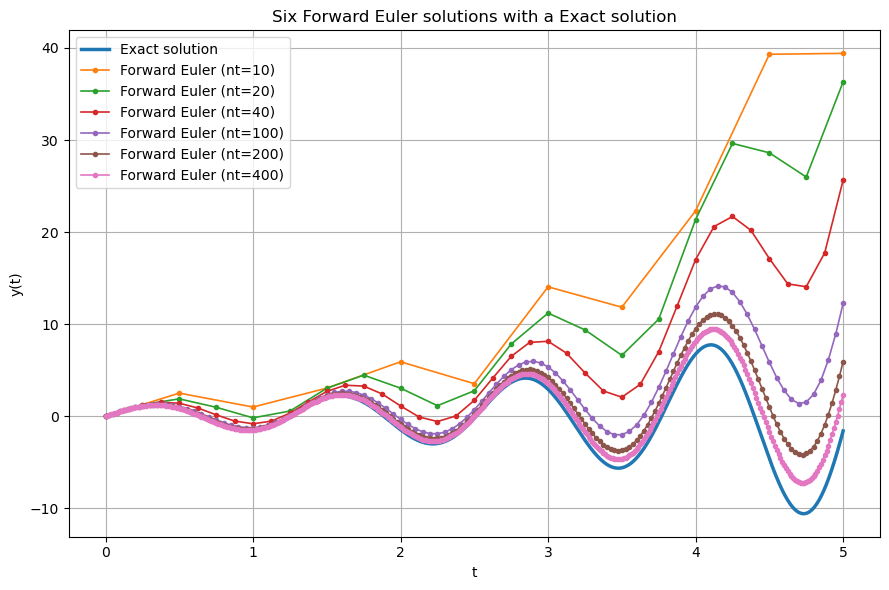

In [ ]:
# 3 forward euler solutions vs exact solution fig
t_dense = np.linspace(t0, T, 2000)
y_dense = exact(t_dense)

plt.figure(figsize=(9, 6))
plt.plot(t_dense, y_dense, linewidth=2.5, label='Exact solution')

for r in results:
    plt.plot(r["t"], r["y"], marker='o', markersize=3, linewidth=1.2,
             label=f'Forward Euler (nt={r["nt"]})')

plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Six Forward Euler solutions with a Exact solution')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

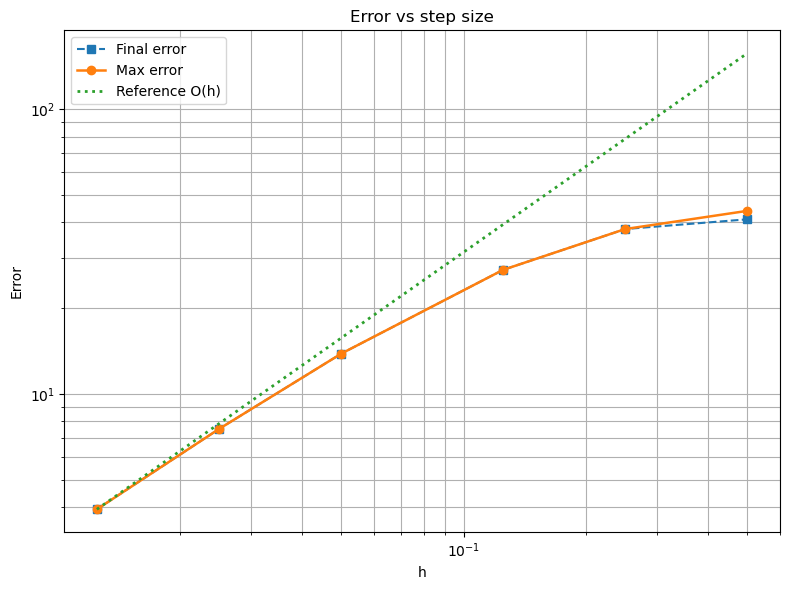

In [ ]:
# 4 Error vs step size

h_vals = np.array([r["h"] for r in results])
final_err_vals = np.array([r["final_err"] for r in results])
max_err_vals = np.array([r["max_err"] for r in results])

idx = np.argsort(h_vals)
h_vals = h_vals[idx]
final_err_vals = final_err_vals[idx]
max_err_vals = max_err_vals[idx]

ref_line = max_err_vals[0] * (h_vals / h_vals[0])

plt.figure(figsize=(8, 6))
plt.loglog(h_vals, final_err_vals, 's--', linewidth=1.5, markersize=6, label='Final error')
plt.loglog(h_vals, max_err_vals, 'o-', linewidth=1.8, markersize=6, label='Max error')
plt.loglog(h_vals, ref_line, ':', linewidth=2.0, label='Reference O(h)')
plt.xlabel('h')
plt.ylabel('Error')
plt.title('Error vs step size')
plt.legend()
plt.grid(True, which='both')
plt.tight_layout()
plt.show()